In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Exercise 07.1 Tail correction


I added a boolean flag `tail_correction` (that has to be specified in input or true by default) and two double:
```C++
double _vtail, _ptail; // Tail corrections
```
## Potential energy tail correction
Inside the function `initialize_properties` if the code measure the potential energy the tail correction is declared as:
```C++ 
_vtail = (_tail_correction)? 
    8*M_PI*_rho/(3.*pow(_r_cut,3)) 
    * (1./(3*pow(_r_cut, 6)) -1 ) : 0.;

```
## Pressure tail correction
Inside the function `initialize_properties` if the code measure the pressure the tail correction is declared as:
```C++ 
_ptail = (_tail_correction)? 
    32*M_PI*_rho*(
        1/(9.*pow(_r_cut, 9)) -1./(6.*pow(_r_cut, 3))
    ) : 0. ; 
```



In [2]:
nt_path='OUTPUT/tail_correction_data/notail/'
acc_nt=pd.read_csv(nt_path+'acceptance.dat', delimiter=r"\s+")
U_nt=pd.read_csv(nt_path+'potential_energy.dat', delimiter=r"\s+")
P_nt=pd.read_csv(nt_path+'pressure.dat', delimiter=r"\s+")

In [3]:
yt_path='OUTPUT/tail_correction_data/tail/'
acc_yt=pd.read_csv(yt_path+'acceptance.dat', delimiter=r"\s+")
U_yt=pd.read_csv(yt_path+'potential_energy.dat', delimiter=r"\s+")
P_yt=pd.read_csv(yt_path+'pressure.dat', delimiter=r"\s+")

Potential tail-notail distance: -0.42834575
Pressure tail-notail distance: -0.6844168500000001


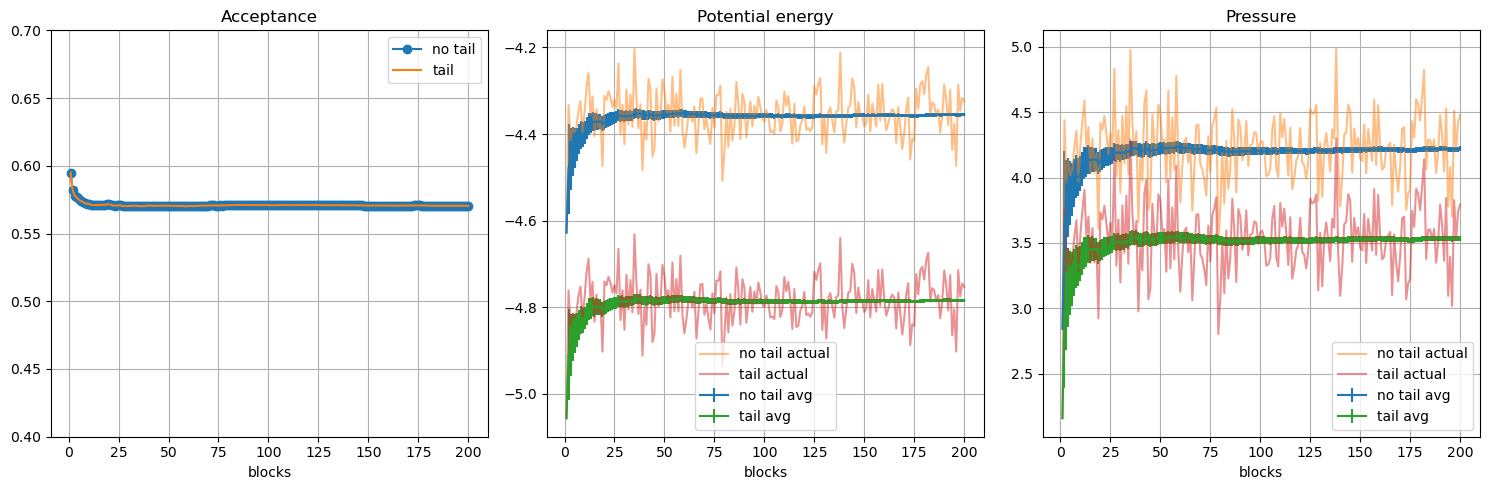

In [4]:
fig, ax= plt.subplots(1, 3, figsize=(15, 5))#, sharex=True)

utail = U_yt['PE_AVE:']-U_nt['PE_AVE:']
ptail = P_yt['P_AVE:']-P_nt['P_AVE:']

print('Potential tail-notail distance:' ,utail.mean())
print('Pressure tail-notail distance:' ,ptail.mean())

ax[0].set_title('Acceptance')
ax[0].plot(acc_nt['#N_BLOCK:'], acc_nt['ACCEPTANCE:'], alpha=1, marker='o',  label='no tail')
ax[0].plot(acc_yt['#N_BLOCK:'], acc_yt['ACCEPTANCE:'], alpha=1, label='tail')
ax[0].set_ylim([0.4, 0.7])

ax[1].set_title('Potential energy')
ax[1].errorbar(U_nt['#BLOCK:'], U_nt['PE_AVE:'], yerr=U_nt['ERROR:'], label='no tail avg')
ax[1].plot(U_nt['#BLOCK:'], U_nt['ACTUAL_PE:'], alpha=0.5, label='no tail actual')

ax[1].errorbar(U_yt['#BLOCK:'], U_yt['PE_AVE:'], yerr=U_yt['ERROR:'], label='tail avg')
ax[1].plot(U_yt['#BLOCK:'], U_yt['ACTUAL_PE:'], alpha=0.5, label='tail actual')

ax[2].set_title('Pressure')
ax[2].errorbar(P_nt['#BLOCK:'], P_nt['P_AVE:'], yerr=P_nt['ERROR:'], label='no tail avg')
ax[2].plot(P_nt['#BLOCK:'], P_nt['ACTUAL_P:'], alpha=0.5, label='no tail actual')

ax[2].errorbar(P_yt['#BLOCK:'], P_yt['P_AVE:'], yerr=P_yt['ERROR:'], label='tail avg')
ax[2].plot(P_yt['#BLOCK:'], P_yt['ACTUAL_P:'], alpha=0.5, label='tail actual')

for k in range(3):
    ax[k].set_xlabel('blocks')
    ax[k].legend()
    ax[k].grid()
plt.tight_layout()
plt.show()

# Exercise 07.2


In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np


## Monte Carlo (N, V, T)

I produced $5*10^5$ blocks of 1 step each.
I plotted the progressive average to see when the mean value became stable and produce a cut-off. 

For a better visualization the number of blocks are cut after $10^4$.

The dt value was setted at 0.1

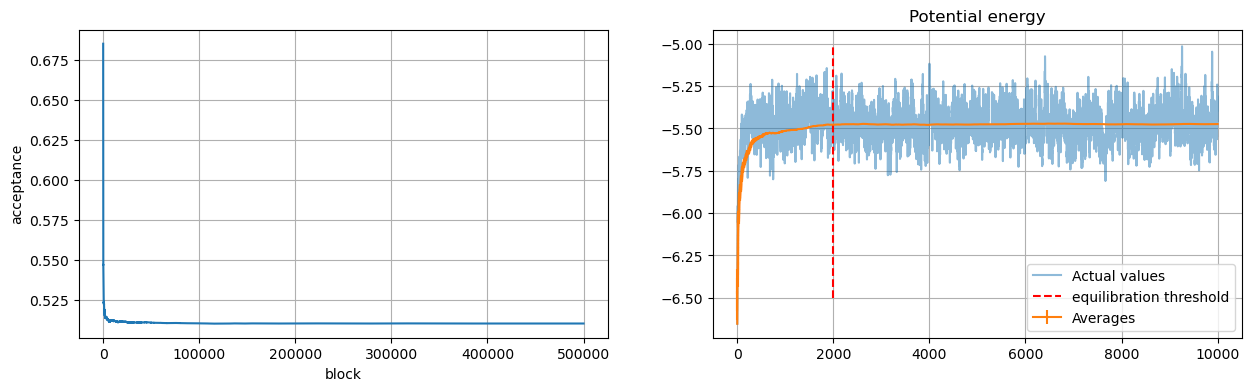

In [6]:
ac_mc=pd.read_csv('OUTPUT/MRT2/acceptance.dat', delimiter=r"\s+")

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
mc_start=2000

ax[0].plot(ac_mc['#N_BLOCK:'],  ac_mc['ACCEPTANCE:'])
ax[0].set_xlabel('block')
ax[0].set_ylabel('acceptance')
ax[0].grid()

U_mc=pd.read_csv('OUTPUT/MRT2/potential_energy.dat',  delimiter=r"\s+")
U_mc


ax[1].set_title('Potential energy')
ax[1].plot(U_mc['#BLOCK:'][:10000], U_mc['ACTUAL_PE:'][:10000], alpha=0.5, label='Actual values')
ax[1].errorbar(U_mc['#BLOCK:'][:10000], U_mc['PE_AVE:'][:10000], yerr=U_mc['ERROR:'][:10000], label='Averages')
ax[1].vlines(mc_start, -6.5, -5, color='r', ls='--', label='equilibration threshold')
ax[1].legend()
ax[1].grid()
plt.show()

## Molecular Dynamics (N,V,E)

Using the same method described for MC i setted the equilibration treshold in the same position to compare the data.

Both temperature and potential energy after $2*10^3$ step seem to converge around an equilibrium value.

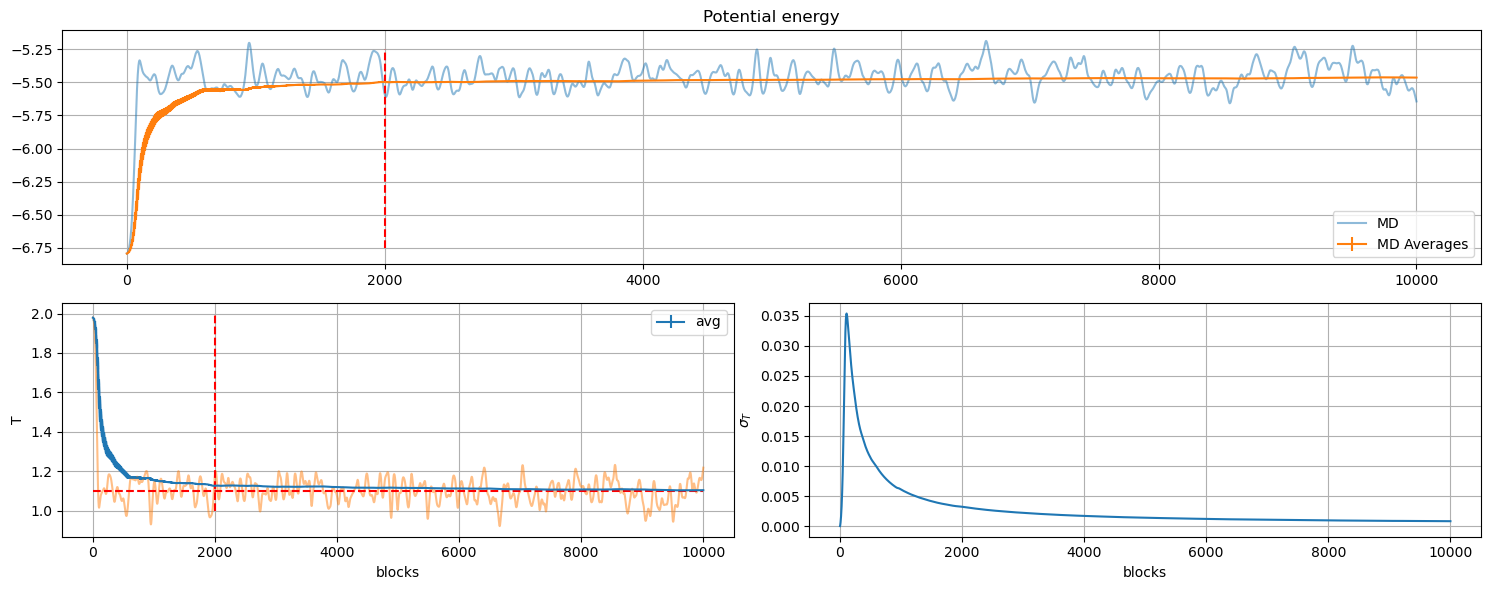

        #BLOCK:  ACTUAL_T:   T_AVE:    ERROR:
499999   500000    1.11893  1.09666  0.000075


In [7]:

U_md=pd.read_csv('OUTPUT/MD/potential_energy.dat',  delimiter=r"\s+")
U_md

cut=10000
md_start=2000

fig = plt.figure(figsize=(15, 6))

ax = plt.subplot(2, 1, 1)
ax.set_title('Potential energy')
ax.plot(U_md['#BLOCK:'][:cut], U_md['ACTUAL_PE:'][:cut], alpha=0.5, label='MD')
ax.errorbar(
    U_md['#BLOCK:'][:cut], U_md['PE_AVE:'][:cut], 
    yerr=U_md['ERROR:'][:cut], label='MD Averages')

ax.vlines(md_start, -6.75, -5.25, ls='--', color='r')

ax.legend()
ax.grid()



temp_md = pd.read_csv('OUTPUT/MD/temperature.dat', delimiter=r"\s+")

#plt.figure(figsize=(10, 5))
ax0 = plt.subplot(2, 2, 3)
ax0.errorbar(
    temp_md['#BLOCK:'][:cut], temp_md['T_AVE:'][:cut],
    yerr=temp_md['ERROR:'][:cut], label='avg',
    #marker='*'
)

# ax0.plot(temp_md['ACTUAL_T:'][:cut].rolling(10000).mean())
ax0.plot(temp_md['#BLOCK:'][:cut], temp_md['ACTUAL_T:'][:cut], alpha=0.5)
ax0.hlines(1.1, 0, cut, ls='--', color='r')
ax0.vlines(md_start, 1., 2., ls='--', color='r')
ax0.set_xlabel('blocks')
ax0.set_ylabel('T')
ax0.grid()
ax0.legend()

ax1 = plt.subplot(2, 2, 4)

ax1.plot(temp_md['#BLOCK:'][:cut], temp_md['ERROR:'][:cut])
ax1.set_xlabel('blocks')
ax1.set_ylabel(r'$\sigma_T$')
ax1.grid()
#plt.xlim([-100, 1000])

plt.tight_layout()
plt.show()

print(temp_md.loc[temp_md.index==len(temp_md)-1])


## Cleaned data

togliere

MD -5.4532659519477935
MC -5.465001886385542


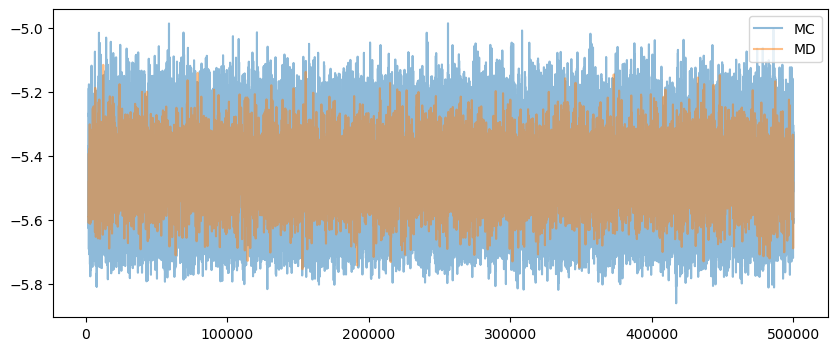

In [29]:
plt.figure(figsize=(10, 4))

mcu = U_mc.loc[U_mc.index>=mc_start].reset_index(drop=True)
mdu = U_md.loc[U_md.index>=md_start].reset_index(drop=True)
plt.plot(mcu['#BLOCK:'], mcu['ACTUAL_PE:'], alpha=0.5, label='MC')
plt.plot(mdu['#BLOCK:'], mdu['ACTUAL_PE:'], alpha=0.5, label='MD')
# plt.hlines(mdu['ACTUAL_PE:'].mean(), 0, 500000, colors='r')
# plt.hlines(mcu['ACTUAL_PE:'].mean(), 0, 500000, colors='r')
print('MD', mdu['ACTUAL_PE:'].mean())
print('MC', mcu['ACTUAL_PE:'].mean())
plt.legend()
plt.show()

In [10]:
from tqdm import tqdm
from scipy.optimize import curve_fit

## Autocorrelation

$$ \chi(t) = \frac{1}{t_{max}-t} \frac{\sum_{t'=0}^{t_{max}-t} m(t')*m(t'+t) - \sum_{t'=0}^{t_{max}-t} m(t') *  \frac{1}{t_{max}-t} *\sum_{t'=0}^{t_{max}-t} m(t'+t)  }
{\frac{1}{t_{max}} \sum_{t'=0}^{t_{max}} m^2 (t') - (\frac{1}{t_{max}} \sum_{t'=0}^{t_{max}} m (t'))^2 } $$

In [11]:
def cor(x:pd.Series, ts):
    return [
        ( (x[:x.size-t]*x[t:]).sum()/(x.size-t) - (x[:x.size-t].mean())*(x[t:].mean()) ) / x.var()    
        for t in tqdm(ts)
    ]

In [12]:
def exp(x, tc):
    return np.exp(-1.*x/tc)

In [13]:
tsup=2000

ts = np.array(range(0, tsup))

s1=cor(mdu['ACTUAL_PE:'].values, ts)
s1MC=cor(mcu['ACTUAL_PE:'].values, ts)

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:07<00:00, 285.64it/s]


In [ ]:
poptmd, pcovmd = curve_fit(exp, ts, s1)
poptmc, pcovmc = curve_fit(exp, ts, s1MC)

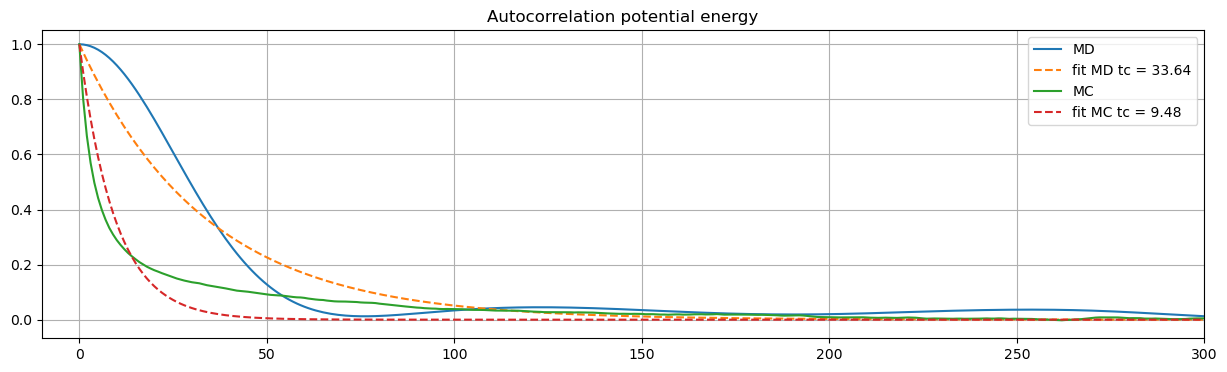

In [117]:

plt.figure(figsize=(15, 4))

plt.title('Autocorrelation potential energy')

plt.plot(ts, s1, label='MD')
plt.plot(ts, exp(ts, poptmd[0]), '--', label=f'fit MD tc = {"%.2f"%poptmd[0]}')

plt.plot(ts, s1MC, label='MC')
plt.plot(ts, exp(ts, poptmc[0]), '--', label=f'fit MC tc = {"%.2f"%poptmc[0]}')

# plt.yscale('log')
plt.xlim([-10, 300])
plt.legend()
plt.grid()
plt.show()

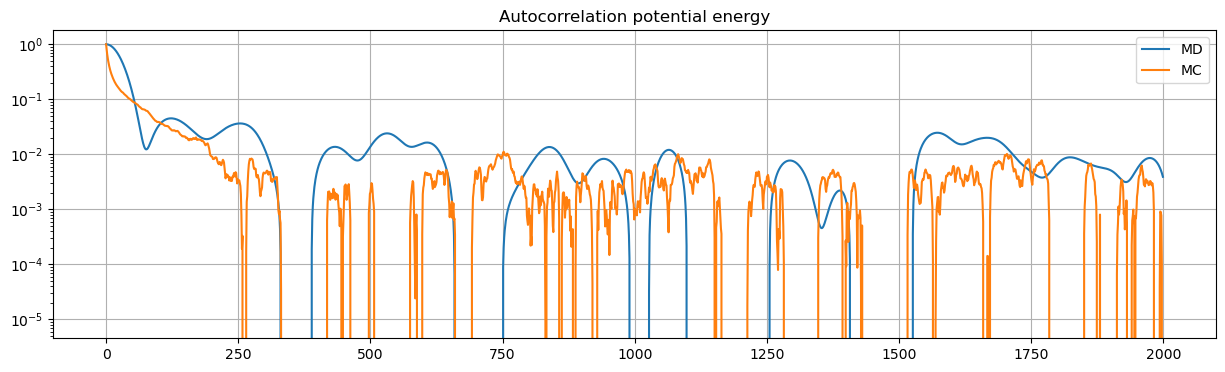

In [80]:
plt.figure(figsize=(15, 4))

plt.title('Autocorrelation potential energy')

plt.plot(range(0,tsup), s1, label='MD')
plt.plot(range(0,tsup), s1MC, label='MC')

plt.yscale('log')
# plt.xlim([-10, 300])
plt.legend()
plt.grid()
plt.show()

### Statistical uncertainties

In [26]:
def unc(df:pd.Series, L:int):
    nblock = df.size//L

    # media sul singolo blocco
    avg = [df[k*L:(k+1)*L].mean()      for k in range(0, nblock)]
    # media single block al quadrato
    av2 = [(df[k*L:(k+1)*L].mean())**2 for k in range(0, nblock)]

    # progrssive avg sull ultimo blocco
    prog_avg = np.sum(avg)/nblock
    prog_av2 = np.sum(av2)/nblock

    err = np.sqrt(
        np.fabs(prog_av2 - ((prog_avg)**2)) /(nblock-1)
        )


    return err#, avg


In [27]:
Ls = range(10, 5000, 10)

md_sgs=[unc(U_md['ACTUAL_PE:'][2000:], L) for L in tqdm(Ls)]
mc_sgs=[unc(U_mc['ACTUAL_PE:'][2000:], L) for L in tqdm(Ls)]

100%|██████████| 499/499 [00:26<00:00, 18.93it/s]


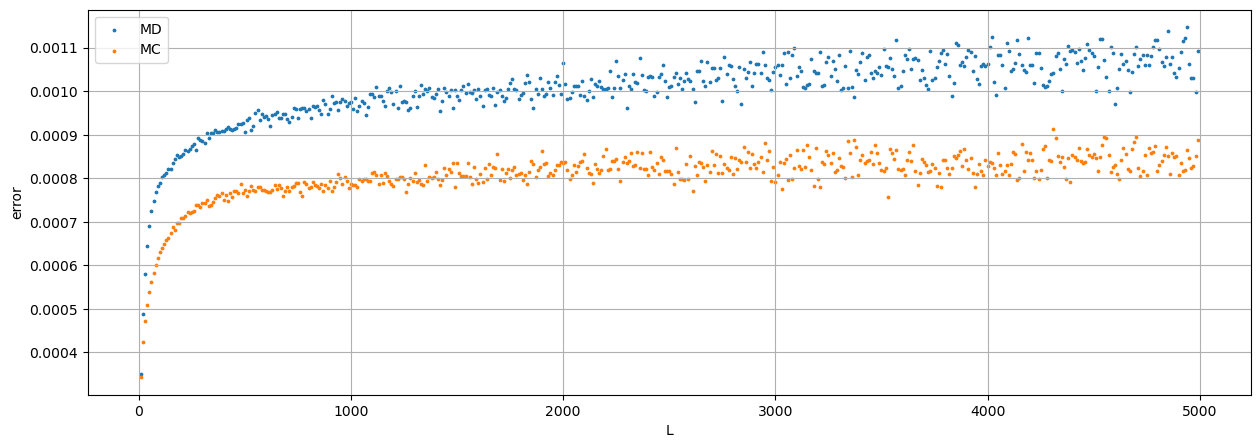

In [44]:
plt.figure(figsize=(15, 5))

plt.scatter(Ls, md_sgs, label='MD', s=3)
plt.scatter(Ls, mc_sgs, label='MC', s=3)
plt.ylabel('error')
plt.xlabel('L')
plt.grid()
plt.legend()
plt.show()

# Exercise 07.3

To measure $g(r)$ the code read the input file and ask to specify the number of bins to calculate the distribution.

Then in  the `measure` function for every couple of particles is calculated the relative distance `dr` and an histogram is filled and the vector `_measurement` is updated:
```C++
int k = floor(_n_bins*dr*2/_side(0));
if(k<_n_bins) _measurement(_index_gofr+k)+=2;
```
After the values are normalized with:
```C++
double binr=0.5*_side(0)/_n_bins; 
for(int i=0; i<_n_bins; i++)
    _measurement(_index_gofr+i)/=
        _rho * _npart * 4.*M_PI/3.
        *(pow(i*binr + binr, 3) - pow(i*binr, 3));
```

Finally in the function `averages` the progressive average is computed and saved on file with the relative uncertainties



## Exercise 07.4

Below are reported the results for g(r), U/N and P with the argon parameters in liquid phase:

$\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)

Both methods MD and MC are reported below.

In [3]:
#  MC
gr_mc= pd.read_csv('OUTPUT/argon/MC/gofr.dat', delimiter=r"\s+")
u_mc = pd.read_csv('OUTPUT/argon/MC/potential_energy.dat', delimiter=r"\s+")
p_mc = pd.read_csv('OUTPUT/argon/MC/pressure.dat', delimiter=r"\s+")

acceptance=pd.read_csv('OUTPUT/argon/MC/acceptance.dat', delimiter=r"\s+")

gr_mc['block']=gr_mc.index//100


# MD
gr_md= pd.read_csv('OUTPUT/argon/MD/gofr.dat', delimiter=r"\s+")
u_md = pd.read_csv('OUTPUT/argon/MD/potential_energy.dat', delimiter=r"\s+")
p_md = pd.read_csv('OUTPUT/argon/MD/pressure.dat', delimiter=r"\s+")

temp = pd.read_csv('OUTPUT/argon/MD/temperature.dat', delimiter=r"\s+")

gr_md['block']=gr_md.index//100


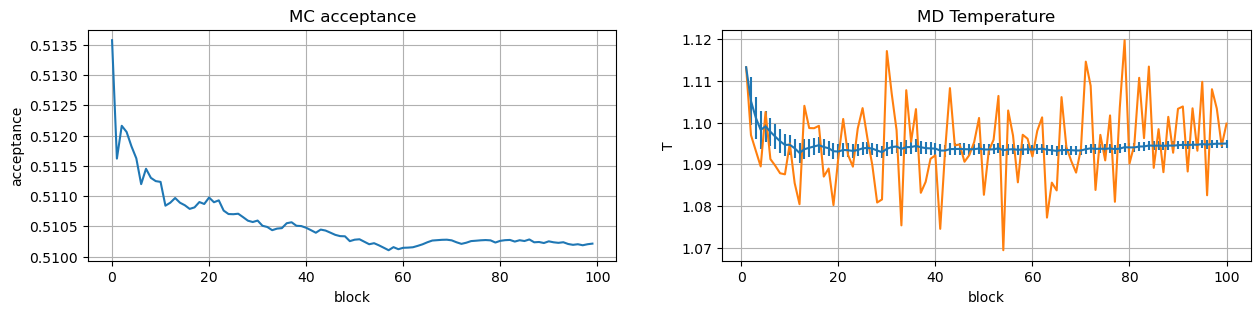

In [4]:
plt.figure(figsize=(15,3))

ax = plt.subplot(1, 2,1)

ax.plot(acceptance['ACCEPTANCE:'])
ax.set_title('MC acceptance')
ax.set_xlabel('block')
ax.set_ylabel('acceptance')
ax.grid()

ax = plt.subplot(1, 2,2)
ax.errorbar(temp['#BLOCK:'], temp['T_AVE:'], yerr=temp['ERROR:'])
ax.plot(temp['#BLOCK:'], temp['ACTUAL_T:'])
ax.set_title('MD Temperature')
ax.set_xlabel('block')
ax.set_ylabel('T')
ax.grid()

plt.show()

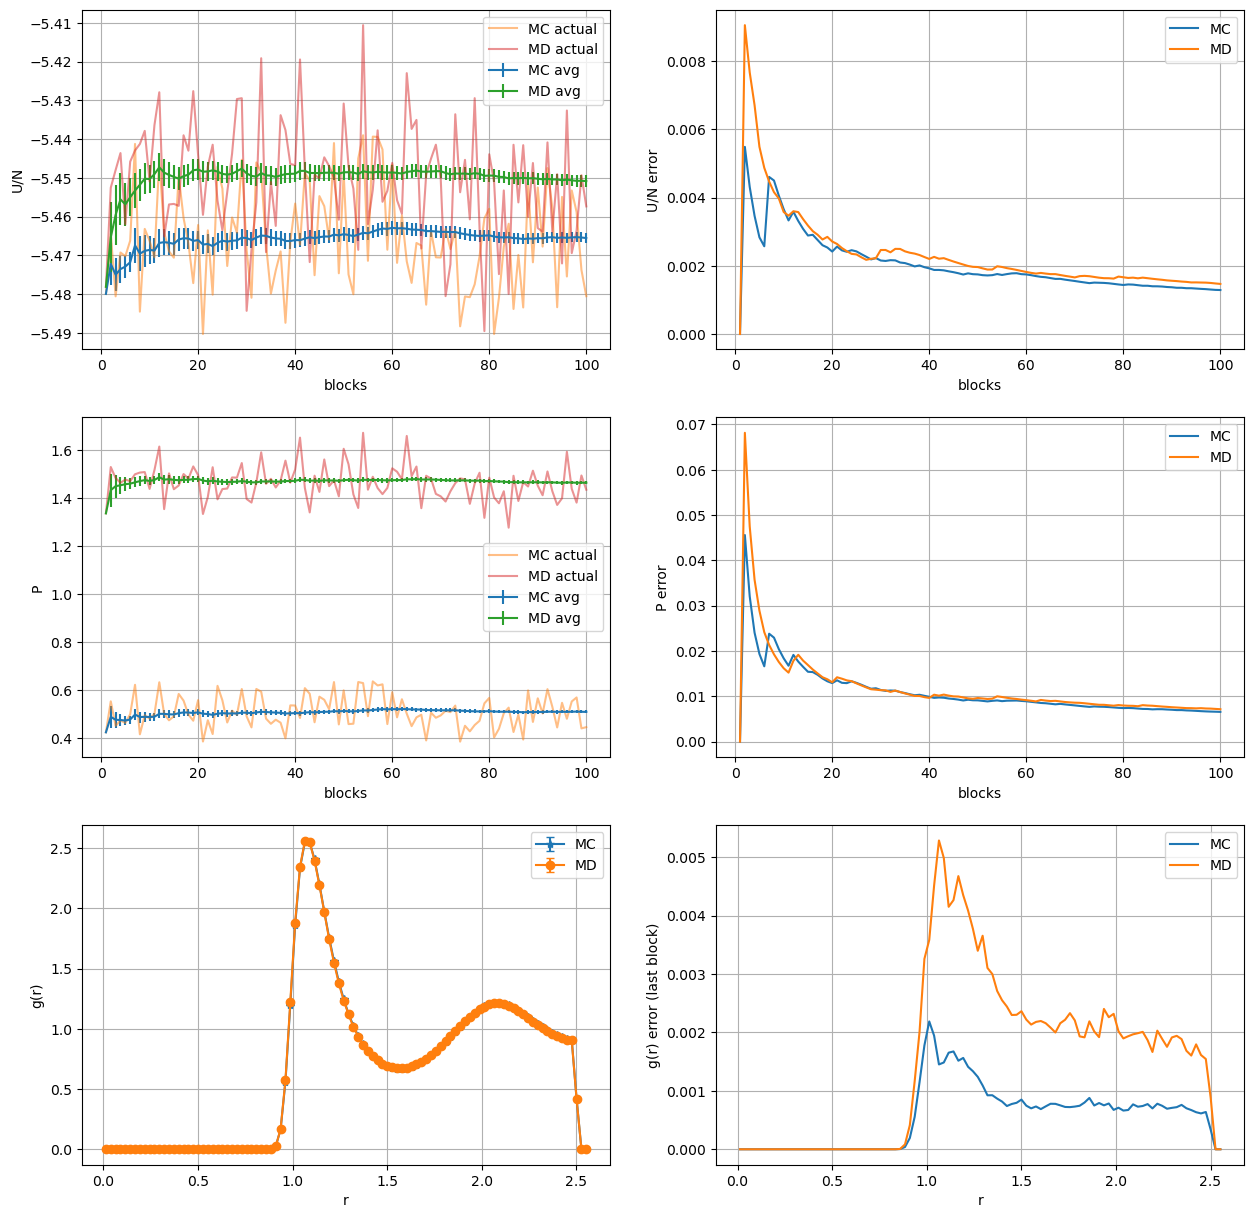

In [10]:
fig, ax = plt.subplots(3, 2, figsize=(15, 15))

ax[0,0].errorbar(u_mc['#BLOCK:'], u_mc['PE_AVE:'], yerr=u_mc['ERROR:'], label='MC avg')
ax[0,0].plot(u_mc['#BLOCK:'], u_mc['ACTUAL_PE:'], alpha=0.5, label='MC actual')
ax[0,0].errorbar(u_md['#BLOCK:'], u_md['PE_AVE:'], yerr=u_md['ERROR:'], label='MD avg')
ax[0,0].plot(u_md['#BLOCK:'], u_md['ACTUAL_PE:'], alpha=0.5, label='MD actual')
ax[0,0].set_xlabel('blocks')
ax[0,0].set_ylabel('U/N')

ax[0,1].plot(u_mc['#BLOCK:'], u_mc['ERROR:'], label='MC')
ax[0,1].plot(u_md['#BLOCK:'], u_md['ERROR:'], label='MD')
ax[0,1].set_xlabel('blocks')
ax[0,1].set_ylabel('U/N error')

ax[1,0].errorbar(p_mc['#BLOCK:'], p_mc['P_AVE:'], yerr=p_mc['ERROR:'], label='MC avg')
ax[1,0].plot(p_mc['#BLOCK:'], p_mc['ACTUAL_P:'], alpha=0.5, label='MC actual')
ax[1,0].errorbar(p_md['#BLOCK:'], p_md['P_AVE:'], yerr=p_md['ERROR:'], label='MD avg')
ax[1,0].plot(    p_md['#BLOCK:'], p_md['ACTUAL_P:'], alpha=0.5, label='MD actual')
ax[1,0].set_xlabel('blocks')
ax[1,0].set_ylabel('P')

ax[1,1].plot(p_mc['#BLOCK:'], p_mc['ERROR:'], label='MC')
ax[1,1].plot(p_md['#BLOCK:'], p_md['ERROR:'], label='MD')
ax[1,1].set_xlabel('blocks')
ax[1,1].set_ylabel('P error')



ax[2,0].errorbar(
    x=gr_mc.loc[gr_mc.block==gr_mc.block.max()]['#DISTANCE:'], 
    y=gr_mc.loc[gr_mc.block==gr_mc.block.max()]['AVE_GOFR:'],
    yerr=gr_mc.loc[gr_mc.block==gr_mc.block.max()]['ERROR:'], 
    marker='*', capsize=3, label='MC'
)

ax[2,0].errorbar(
    x=   gr_md.loc[gr_md.block==gr_md.block.max()]['#DISTANCE:'], 
    y=   gr_md.loc[gr_md.block==gr_md.block.max()]['AVE_GOFR:'],
    yerr=gr_md.loc[gr_md.block==gr_md.block.max()]['ERROR:'], 
    marker='o', capsize=3, label='MD'
)

ax[2,0].set_xlabel('r')
ax[2,0].set_ylabel('g(r)')

ax[2,1].plot(gr_mc.loc[gr_mc['block']==gr_mc['block'].max()]['#DISTANCE:'], gr_mc.loc[gr_mc['block']==gr_mc['block'].max()]['ERROR:'], label='MC') 
ax[2,1].plot(gr_md.loc[gr_md['block']==gr_md['block'].max()]['#DISTANCE:'], gr_md.loc[gr_md['block']==gr_md['block'].max()]['ERROR:'], label='MD') 

ax[2,1].set_xlabel('r')
ax[2,1].set_ylabel('g(r) error (last block)')

for i in range(3):
    for j in range(2):
        ax[i,j].grid()
        ax[i,j].legend()

